In [1]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import collections

In [44]:
data = pd.read_csv("final_defesas_2006a2024.csv")
ano_interesse = 2024
data = data[data["ano"]==ano_interesse]

In [45]:
data["orientador_nome"].value_counts()

orientador_nome
Julio Cesar Dos Reis                6
Anderson Rocha                      5
Helio Pedrini                       4
Marcelo Reis                        4
Leandro Villas                      3
Guido Araujo                        3
Edson Borin                         3
Alexandre Falcao                    3
Julio Cesar Lopez Hernandez         3
Luiz Fernando Bittencourt           2
Sandra Avila                        2
André Santanchè                     2
Maria Cecilia Calani Baranauskas    2
Zanoni Dias                         2
BULGARELI, J V                      1
Marcos M. Raimundo                  1
Jacques Wainer                      1
Fábio Usberti                       1
Rafael C. S. Schouery               1
Lucas Wanner                        1
Rodolfo Azevedo                     1
Ricardo Torres                      1
Edmundo Madeira                     1
Pedro J. de Rezende                 1
Name: count, dtype: int64

In [48]:
data["orientador_genero"].value_counts()

orientador_genero
Masculino    49
Feminino      5
Name: count, dtype: int64

## Criação dos grafos e dos nós

In [16]:
index

0

In [35]:
grafo_defesas = nx.MultiDiGraph()
# grafo_defesas = nx.DiGraph()
n_banca = 0
for col in data.columns[2:]:
    if "_" in col: continue
    if col == "ano": continue
    # if "orientador" not in "col"
    for index, url in zip(data[col].index, data[col]):
        if url != url: continue
        elif url == "sem orcid": continue
        grafo_defesas.add_node(url.split("/")[-1],
                            #    papel=col,
                               nome=data.at[index, f"{col}_nome"],
                               filiacao=data.at[index, f"{col}_filiação"],
                               orcid=url.split("/")[-1],
                               genero=data.at[index, f"{col}_genero"])
    n_banca -=- 1

In [36]:
for row in data.iterrows():
    # print(row[0], row[1]["orientador"])
    # break
    # a.add_edge(row[1]["orientador"], row[1]["avaliador1"])
    if row[1]["orientador"] != row[1]["orientador"]: continue
    if row[1]["orientador"] == "sem orcid": continue
    orcid_orient = row[1]["orientador"].split("/")[-1]
    for i in range(1, n_banca):
        if row[1][f"avaliador{i}"] != row[1][f"avaliador{i}"]: continue
        if row[1][f"avaliador{i}"] == "sem orcid": continue
        # if "Eliane Martins" == row[1][f"avaliador{i}_nome"].split("/")[-1]: print("ola_aval")
        # if "Eliane Martins" == row[1][f"orientador_nome"].split("/")[-1]: print("ola_orient")
        orcid_aval = row[1][f"avaliador{i}"].split("/")[-1]
        # if grafo_defesas.has_edge(orcid_orient, orcid_aval):
        #     grafo_defesas[orcid_orient][orcid_aval]["qtd"] -=- 1
        #     continue
        grafo_defesas.add_edge(orcid_orient, orcid_aval, qtd=1)
        ## aresta direcionada: orientadora/orientador -> avaliador/avaliadora
        # grafo_defesas.add_(orcid_orient, orcid_aval, qtd=1)
edge_widths = []
# for p1, p2 in grafo_defesas.edges:
#     edge_widths.append(1 * grafo_defesas[p1][p2]["qtd"])

## Cálculos dos graus máximo e mínimo

In [37]:
max_degree_in = 0
max_degree_out = 0
for no, degree in grafo_defesas.in_degree():
    if degree > max_degree_in:
        max_degree_in = degree
max_degree_person_in = [no for no, degree in grafo_defesas.in_degree() if degree == max_degree_in]

for no, degree in grafo_defesas.out_degree():
    if degree > max_degree_out:
        max_degree_out = degree
max_degree_person_out = [no for no, degree in grafo_defesas.out_degree() if degree == max_degree_out]

In [38]:
nodes_lists = collections.defaultdict(list)
for no in grafo_defesas.nodes():
    nodes_lists[grafo_defesas.nodes[no]["genero"]].append(no)

Text(0.5, 1.0, '2006')

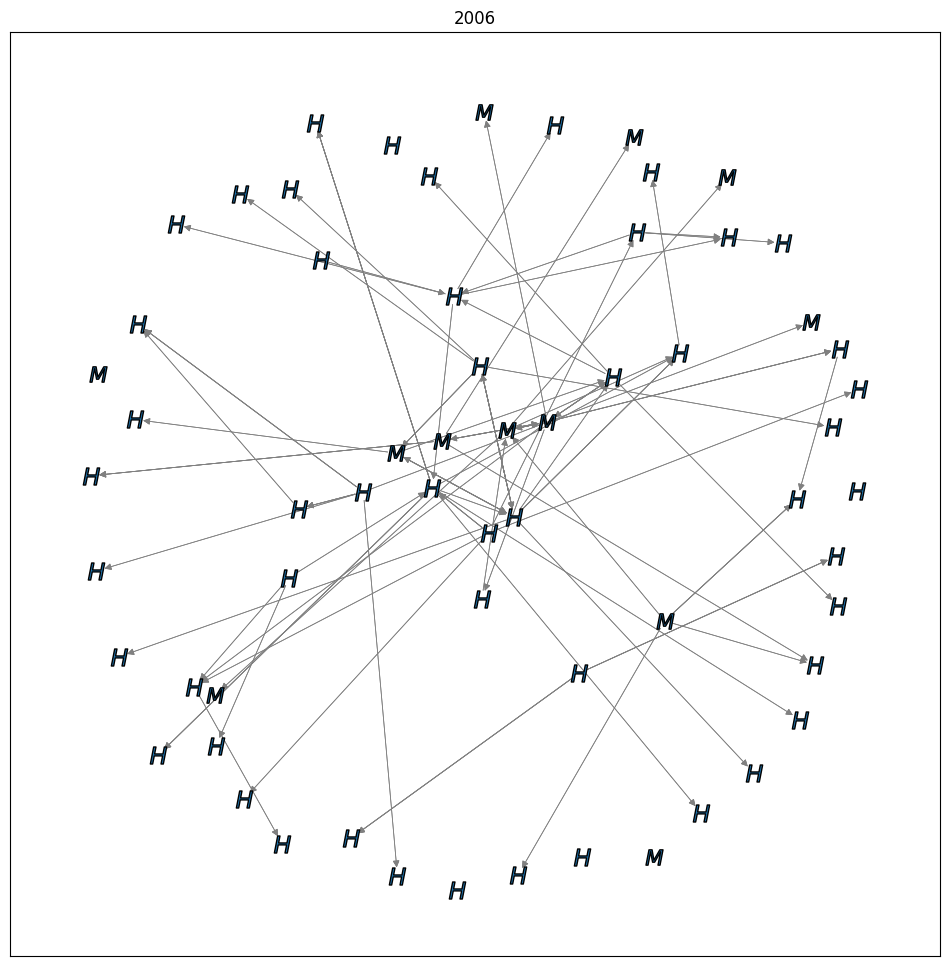

In [39]:
fig, ax = plt.subplots(nrows=1, figsize=(12, 12), )#dpi=300)
pos = nx.spring_layout(grafo_defesas, seed=42, k=.5)
for gender in nodes_lists.keys():
    nodes_2_plot = nodes_lists[gender]
    gender_marker = "o"
    if gender == "Feminino":
        gender_marker = "$M$"
    elif gender == "Masculino":
        gender_marker = "$H$"
    nx.draw_networkx(
        grafo_defesas,
        pos=pos,
        node_size=150,
        nodelist=nodes_2_plot,
        # node_color=["red" if G.degree(v) == 0 else "skyblue" for v in G.nodes],
        node_shape = gender_marker,
        edge_color="gray", width=.55,
        edgecolors="k", linewidths=1,
        with_labels=False,
        ax=ax
    )
plt.title(f"{ano_interesse}")

In [23]:
node_shape = []
for v in grafo_defesas.nodes:
    # genero = data
    node_shape.append("<" if grafo_defesas.nodes[v]["genero"] == "Masculine" else ">")
    # print(v)
    # print(grafo_defesas.nodes[v]["genero"])
    # break

### Gráfico log-log com graus de saída (orientação->avaliação)

In [24]:
degree_sequence = [d for _, d in grafo_defesas.out_degree()]  # list of degrees
gender_sequence = ["<" if grafo_defesas.nodes[v]["genero"] == "Masculino" else ">" for v, _ in grafo_defesas.out_degree()]  # list of degrees
degree_count = collections.Counter(degree_sequence)
deg, cnt = zip(*sorted(degree_count.items()))
# _, shape = zip(*sorted(node_shape.items()))

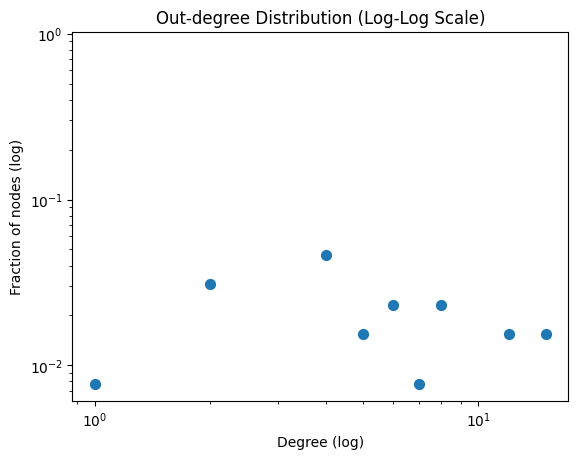

In [25]:
fig, ax = plt.subplots()
for deg, cnt in sorted(degree_count.items()):
    ax.scatter(deg, cnt/len(grafo_defesas), s=50, color="#1f78b4")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Degree (log)")
plt.ylabel("Fraction of nodes (log)")
plt.title("Out-degree Distribution (Log-Log Scale)")
# plt.show()
plt.show()

### Gráfico log-log com graus de entrada (avaliação<-orientação)

In [26]:
degree_sequence = [d for _, d in grafo_defesas.in_degree()]  # list of degrees
gender_sequence = ["<" if grafo_defesas.nodes[v]["genero"] == "Masculino" else ">" for v, _ in grafo_defesas.out_degree()]  # list of degrees
degree_count = collections.Counter(degree_sequence)
deg, cnt = zip(*sorted(degree_count.items()))
# _, shape = zip(*sorted(node_shape.items()))

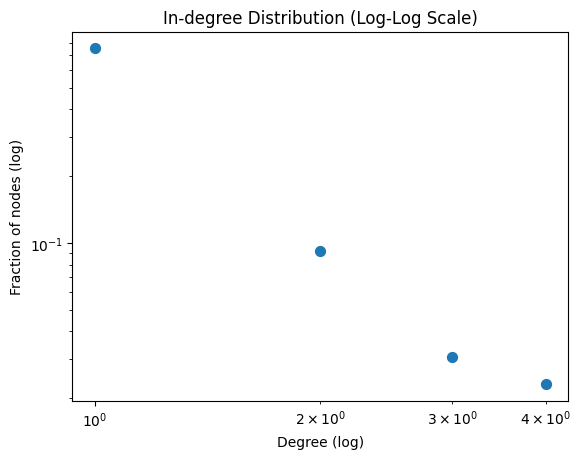

In [27]:
fig, ax = plt.subplots()
for deg, cnt in sorted(degree_count.items()):
    ax.scatter(deg, cnt/len(grafo_defesas), s=50, color="#1f78b4")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Degree (log)")
plt.ylabel("Fraction of nodes (log)")
plt.title("In-degree Distribution (Log-Log Scale)")
# plt.show()
plt.show()

### Gráfico log-log com graus de entrada e saída

In [29]:
degree_sequence = [d for _, d in grafo_defesas.degree()]  # list of degrees
gender_sequence = ["<" if grafo_defesas.nodes[v]["genero"] == "Masculino" else ">" for v, _ in grafo_defesas.out_degree()]  # list of degrees
degree_count = collections.Counter(degree_sequence)
deg, cnt = zip(*sorted(degree_count.items()))
# _, shape = zip(*sorted(node_shape.items()))

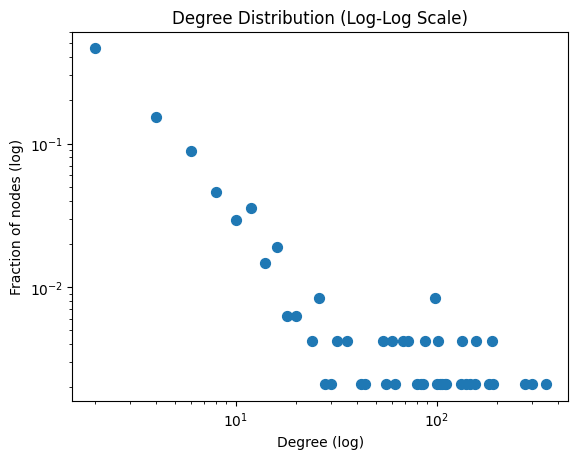

In [30]:
fig, ax = plt.subplots()
for deg, cnt in sorted(degree_count.items()):
    ax.scatter(deg, cnt/len(grafo_defesas), s=50, color="#1f78b4")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Degree (log)")
plt.ylabel("Fraction of nodes (log)")
plt.title("Degree Distribution (Log-Log Scale)")
# plt.show()
plt.show()